# LASSO Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv('./cleaned_property_data.csv')

In [3]:
X = df.drop(columns=["Super Buildup Rate (per sq.ft.)"], errors="ignore")
y = df["Super Buildup Rate (per sq.ft.)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
model = Lasso(alpha=1.0)
model.fit(X_train, y_train)

Lasso()

In [5]:
y_pred = model.predict(X_test)

In [7]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Lasso Regression Results")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Lasso Regression Results
MAE: 0.58
RMSE: 0.73
R² Score: 0.4217


In [8]:
train_r2 = r2_score(y_train,model.predict(X_train))
print(f"Train R² Score: {train_r2:.4f}")

Train R² Score: 0.4380


#### Applying cross validation

In [10]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for R² score
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Cross-validated R² scores:", cv_scores)
print(f"Mean R² score: {cv_scores.mean():.4f}")

Cross-validated R² scores: [0.41925589 0.44430359 0.42410082 0.4452475  0.43677856]
Mean R² score: 0.4339


- Since the model accuracy is too low , might the value of alpha is not good.

### using LassoCV to select best alpha value

In [11]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(-3, 3, 50)

# LassoCV automatically selects the best alpha using cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

print(f"Best alpha: {lasso_cv.alpha_}")
print(f"Train R² Score: {lasso_cv.score(X_train, y_train):.4f}")
print(f"Test R² Score: {lasso_cv.score(X_test, y_test):.4f}")

Best alpha: 0.001
Train R² Score: 0.9827
Test R² Score: 0.9802


#### Comparision of model with different alpha values

In [12]:
def get_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MSE: {mse:.2f}, R²: {r2:.2f}")
    return mse, r2

In [ ]:
y_pred = model.predict(X_test)
y_pred_cv = lasso_cv.predict(X_test)

In [17]:
mse_model, r2_model = get_metrics(y_test, y_pred, "Lasso alpha = 1")
mse_cv, r2_cv = get_metrics(y_test, y_pred_cv, "Lasso CV (alpha = 0.001)")

Lasso alpha = 1 -> MSE: 0.53, R²: 0.42
Lasso CV (alpha = 0.001) -> MSE: 0.02, R²: 0.98


#### 1. Regression fit vs actual

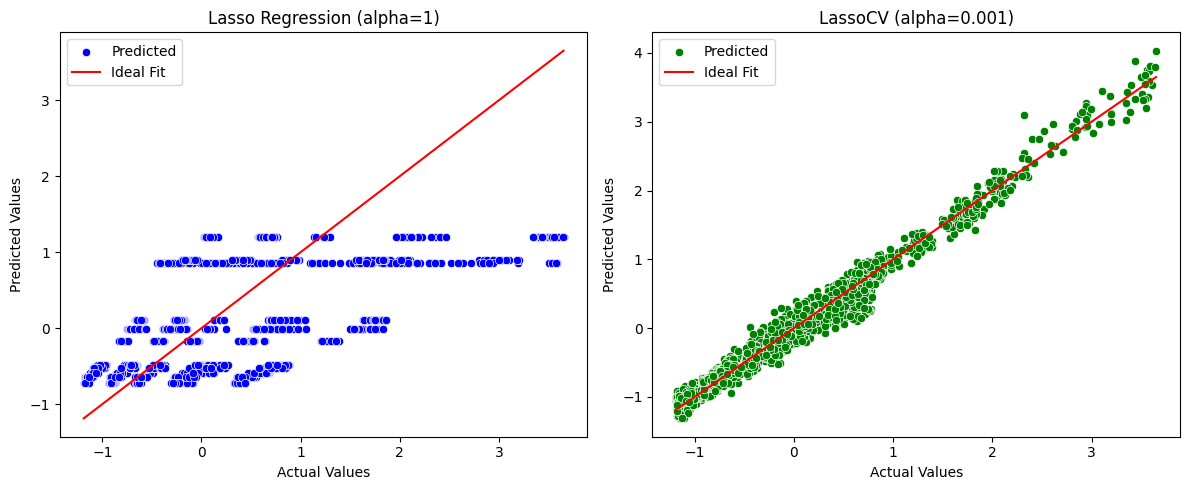

In [20]:
plt.figure(figsize=(12,5))

# Lasso alpha = 1
plt.subplot(1,2,1)
sns.scatterplot(x=y_test, y=y_pred, color="blue", label="Predicted")
sns.lineplot(x=y_test, y=y_test, color="red", label="Ideal Fit")
plt.title("Lasso Regression (alpha=1)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()

# Lasso CV (alpha = 0.001)
plt.subplot(1,2,2)
sns.scatterplot(x=y_test, y=y_pred_cv, color="green", label="Predicted")
sns.lineplot(x=y_test, y=y_test, color="red", label="Ideal Fit")
plt.title("LassoCV (alpha=0.001)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()

plt.tight_layout()
plt.show()


#### 2. Residual Plots

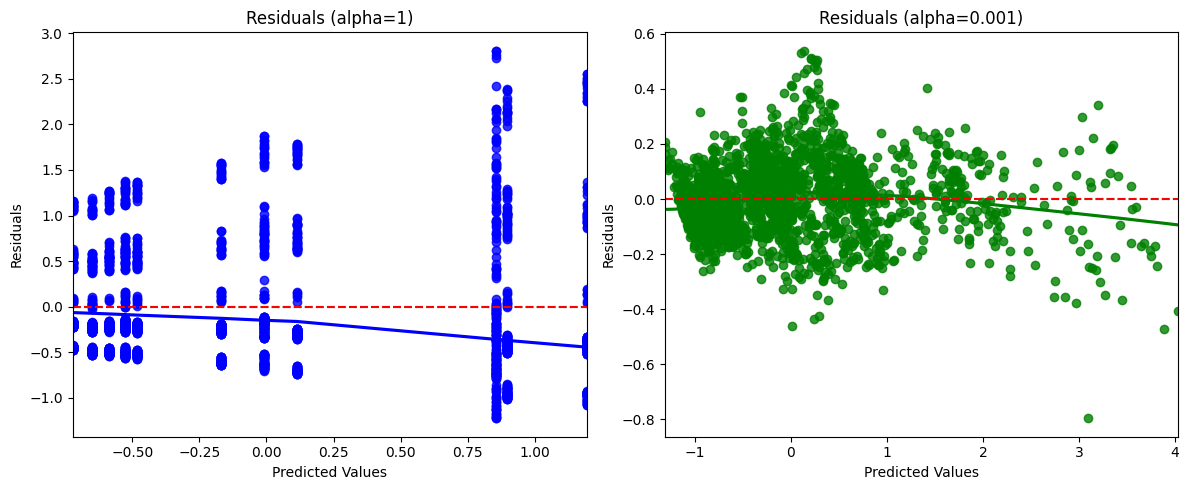

In [21]:
plt.figure(figsize=(12,5))

# Lasso alpha = 1
plt.subplot(1,2,1)
sns.residplot(x=y_pred, y=y_test - y_pred, lowess=True, color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals (alpha=1)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# Lasso CV (alpha = 0.001)
plt.subplot(1,2,2)
sns.residplot(x=y_pred_cv, y=y_test - y_pred_cv, lowess=True, color="green")
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals (alpha=0.001)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()


#### 3.Performance Comparison (MSE & R²)

C:\Users\Dell\AppData\Local\Temp\ipykernel_26852\2049968520.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="MSE", data=metrics, palette="Blues")
C:\Users\Dell\AppData\Local\Temp\ipykernel_26852\2049968520.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="R²", data=metrics, palette="Greens")


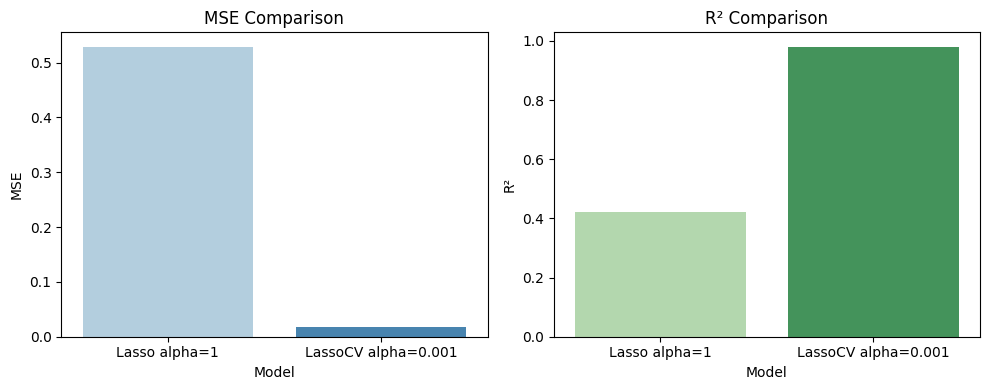

In [22]:
metrics = {
    "Model": ["Lasso alpha=1", "LassoCV alpha=0.001"],
    "MSE": [mse_model, mse_cv],
    "R²": [r2_model, r2_cv]
}

plt.figure(figsize=(10,4))

# Plot MSE
plt.subplot(1,2,1)
sns.barplot(x="Model", y="MSE", data=metrics, palette="Blues")
plt.title("MSE Comparison")

# Plot R²
plt.subplot(1,2,2)
sns.barplot(x="Model", y="R²", data=metrics, palette="Greens")
plt.title("R² Comparison")

plt.tight_layout()
plt.show()
